# Task 1: Data Understanding & Preparation

This notebook covers the first module of the DM1 project (30 pts).  
We will:
1. **Data Semantics** -- describe every variable, its type, and its meaning.
2. **Distributions & Statistics** -- explore single variables and pairs of variables.
3. **Data Quality** -- find errors, outliers, missing values, and semantic problems. Test variable transformations (e.g. log).
4. **Pairwise Correlations** -- build a correlation matrix, find highly correlated pairs, and remove the ones that are not needed.

All comments are written in simple English so they are easy to read.


## 0. Setup
We load the libraries we need and set a nice plot style.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Our helper module
import sys, os
sys.path.append(os.path.abspath('../src'))
from plotting import save_plot, setup_style

setup_style()
%matplotlib inline


In [2]:
# Load the raw dataset
df = pd.read_csv('../dataset/DM1_game_dataset.csv')
print(f'The dataset has {df.shape[0]} rows and {df.shape[1]} columns.')
df.head()


The dataset has 21925 rows and 46 columns.


,BGGId,Name,Description,YearPublished,GameWeight,ComWeight,MinPlayers,MaxPlayers,ComAgeRec,LanguageEase,...,Rank:childrensgames,Cat:Thematic,Cat:Strategy,Cat:War,Cat:Family,Cat:CGS,Cat:Abstract,Cat:Party,Cat:Childrens,Rating
0,140386,Assassin's Creed: Arena,game description publisherin assassins creed a...,2014,1.8333,2.0512,2,4,8.0,213.0,...,21926,0,0,0,0,0,0,0,0,Low
1,344114,Bag of Chips,bag chip party game face crucial choice score ...,2021,1.0000,1.2256,2,5,8.0,36.0,...,21926,0,0,0,0,0,0,0,0,Medium
2,319196,Gùgōng: Deluxe Big Box,big box contain component gugravegng deluxe ed...,2020,3.6667,3.8190,1,5,NaN,NaN,...,21926,0,0,0,0,0,0,0,0,High
3,11404,LetterFlip,publisherthe reveal game secret wordsletterfli...,2004,1.3077,1.4216,2,2,7.0,NaN,...,21926,0,0,0,0,0,0,0,0,Low
4,281020,Treasures of Cibola,rescue mayan treasure easy task ...,2019,1.5000,1.6230,2,4,NaN,7.0,...,21926,0,0,0,0,0,0,0,0,Medium


## 1. Data Semantics

The dataset contains information about **more than 20 000 board games** rated by an online community.  
Below we list every variable, its meaning, its data type, and what kind of variable it is.

| # | Variable | Meaning | Pandas dtype | Kind |
|---|----------|---------|-------------|------|
| 1 | BGGId | Unique game id | int | Identifier |
| 2 | Name | Name of the game | object (text) | Text |
| 3 | Description | Text description of the game | object (text) | Text |
| 4 | YearPublished | Year the game was published | int | Numerical |
| 5 | GameWeight | Game complexity rated 1-5 | float | Numerical (continuous) |
| 6 | ComWeight | Community-recommended complexity 1-5 | float | Numerical (continuous) |
| 7 | MinPlayers | Minimum number of players | int | Numerical (discrete) |
| 8 | MaxPlayers | Maximum number of players | int | Numerical (discrete) |
| 9 | ComAgeRec | Community recommended minimum age | float | Numerical (continuous) |
| 10 | LanguageEase | Language requirement (higher = harder) | float | Numerical (continuous) |
| 11 | BestPlayers | Community voted best player count | int | Numerical (discrete) |
| 12 | GoodPlayers | List of good player counts | object (list as text) | Text / List |
| 13 | NumOwned | Number of users who own the game | int | Numerical (discrete) |
| 14 | NumWant | Number of users who want the game | int | Numerical (discrete) |
| 15 | NumWish | Number of users who wishlisted the game | int | Numerical (discrete) |
| 16 | NumWeightVotes | Number of votes for game weight | int | Numerical (discrete) |
| 17 | MfgPlaytime | Manufacturer stated play time (min) | int | Numerical (discrete) |
| 18 | ComMinPlaytime | Community minimum play time (min) | int | Numerical (discrete) |
| 19 | ComMaxPlaytime | Community maximum play time (min) | int | Numerical (discrete) |
| 20 | MfgAgeRec | Manufacturer recommended age | int | Numerical (discrete) |
| 21 | NumUserRatings | Number of user ratings | int | Numerical (discrete) |
| 22 | NumComments | Number of user comments | int | Numerical (discrete) |
| 23 | NumAlternates | Number of alternate versions | int | Numerical (discrete) |
| 24 | NumExpansions | Number of expansions | int | Numerical (discrete) |
| 25 | NumImplementations | Number of implementations | int | Numerical (discrete) |
| 26 | IsReimplementation | Is this a reimplementation? (0/1) | int | Binary |
| 27 | Family | Game family it belongs to | object (text) | Categorical (text) |
| 28 | Kickstarted | From a crowdfunding project? (0/1) | int | Binary |
| 29 | ImagePath | URL to game image | object (text) | Text (URL) |
| 30-37 | Rank:* | Rank in each sub-category (21926 = unranked) | int | Numerical / Ordinal |
| 38-45 | Cat:* | Binary flag for each category (0/1) | int | Binary |
| 46 | Rating | Game rating: Low, Medium, High | object | **Target** (Ordinal categorical) |


### Quick data-type summary
Let us also check the types and missing values programmatically.


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21925 entries, 0 to 21924
Data columns (total 46 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   BGGId                21925 non-null  int64  
 1   Name                 21925 non-null  object 
 2   Description          21924 non-null  object 
 3   YearPublished        21925 non-null  int64  
 4   GameWeight           21925 non-null  float64
 5   ComWeight            21925 non-null  float64
 6   MinPlayers           21925 non-null  int64  
 7   MaxPlayers           21925 non-null  int64  
 8   ComAgeRec            16395 non-null  float64
 9   LanguageEase         16034 non-null  float64
 10  BestPlayers          21925 non-null  int64  
 11  GoodPlayers          21925 non-null  object 
 12  NumOwned             21925 non-null  int64  
 13  NumWant              21925 non-null  int64  
 14  NumWish              21925 non-null  int64  
 15  NumWeightVotes       21925 non-null 

In [4]:
# How many unique values does each column have?
df.nunique().to_frame('unique_values')


,unique_values
BGGId,21925
Name,21521
Description,21903
YearPublished,188
GameWeight,3921
ComWeight,14383
MinPlayers,11
MaxPlayers,54
ComAgeRec,1366
LanguageEase,3794


## 2. Distribution of the Variables and Statistics

We explore both **single variables** and **pairs of variables** using numbers and plots.  
The guideline says: *"Explore (single, pairs of...) variables quantitatively (statistics, distributions)."*


### 2.1 Summary statistics for all numeric variables


In [5]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
BGGId,21925.0,117652.663216,104628.721777,1.0,12346.000000,105305.0000,206169.0000,349161.0000
YearPublished,21925.0,1985.494914,212.486214,-3500.0,2001.000000,2011.0000,2017.0000,2021.0000
GameWeight,21925.0,1.982131,0.848983,0.0,1.333300,1.9688,2.5252,5.0000
ComWeight,21925.0,2.177479,0.861781,0.0,1.513400,2.1280,2.7377,5.2132
MinPlayers,21925.0,2.007343,0.693093,0.0,2.000000,2.0000,2.0000,10.0000
MaxPlayers,21925.0,5.707868,15.014643,0.0,4.000000,4.0000,6.0000,999.0000
ComAgeRec,16395.0,10.004391,3.269157,2.0,8.000000,10.0000,12.0000,21.0000
LanguageEase,16034.0,216.461819,236.595136,1.0,24.027778,138.0000,351.0000,1757.0000
BestPlayers,21925.0,0.311517,1.067002,0.0,0.000000,0.0000,0.0000,15.0000
NumOwned,21925.0,1467.848164,5294.120574,0.0,150.000000,320.0000,899.0000,166497.0000


### 2.2 Target variable: Rating
Rating is the variable we must predict in the Classification task. Let us see how it is distributed.


In [6]:
print(df['Rating'].value_counts())
print()
print('Percentages:')
print(df['Rating'].value_counts(normalize=True).round(3) * 100)


Rating
Medium    9644
Low       7245
High      5036
Name: count, dtype: int64

Percentages:
Rating
Medium    44.0
Low       33.0
High      23.0
Name: proportion, dtype: float64


Plot saved to: C:\Users\ihsynzd\Documents\Dev\Github\datascience\datamining part 1\src\../report/images\task_1/rating_distribution.png


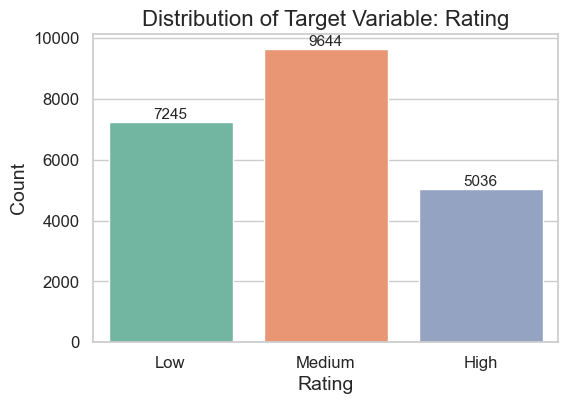

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))
order = ['Low', 'Medium', 'High']
sns.countplot(x='Rating', data=df, order=order, palette='Set2', ax=ax)
ax.set_title('Distribution of Target Variable: Rating')
ax.set_ylabel('Count')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2., p.get_height()),
               ha='center', va='bottom', fontsize=11)
save_plot(fig, 'task_1/rating_distribution.png')
plt.show()


**Discussion:** The classes are not perfectly balanced. Medium is the largest class (44%), Low is in the middle (33%) and High is the smallest (23%).   
This means we should be careful with evaluation metrics later (accuracy alone may not be enough).


### 2.3 Single-variable distributions for key numeric features
We plot histograms and boxplots side by side for the most important numeric columns.  
Boxplots help us see outliers clearly.


Plot saved to: C:\Users\ihsynzd\Documents\Dev\Github\datascience\datamining part 1\src\../report/images\task_1/single_variable_distributions.png


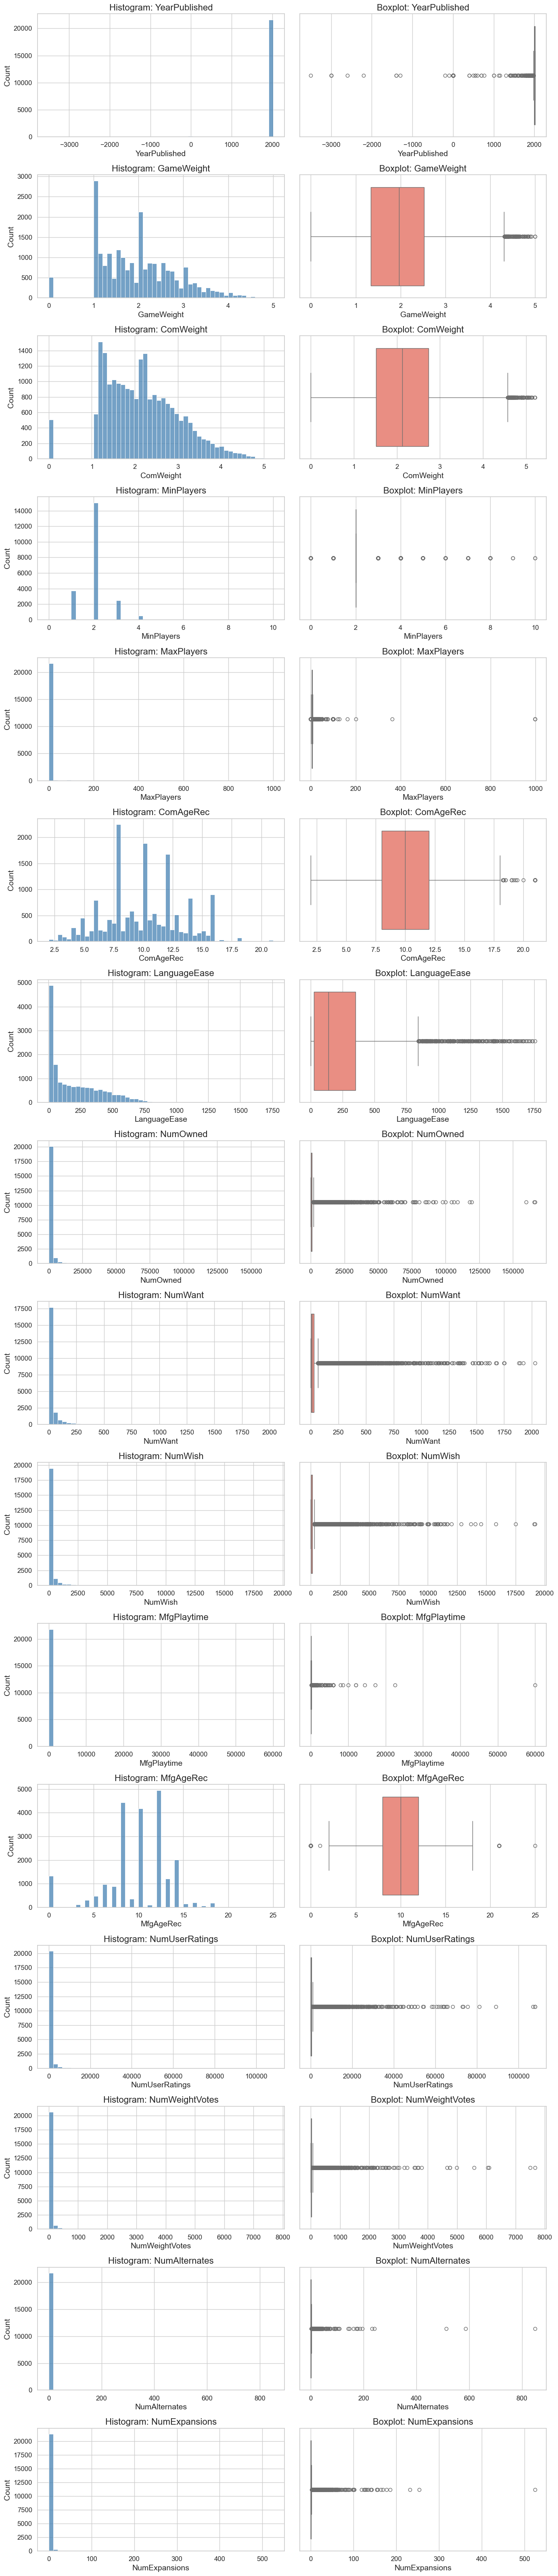

In [8]:
# Select the key numeric columns we want to explore
key_numeric = ['YearPublished', 'GameWeight', 'ComWeight', 'MinPlayers', 'MaxPlayers',
               'ComAgeRec', 'LanguageEase', 'NumOwned', 'NumWant', 'NumWish',
               'MfgPlaytime', 'MfgAgeRec', 'NumUserRatings', 'NumWeightVotes',
               'NumAlternates', 'NumExpansions']

fig, axes = plt.subplots(len(key_numeric), 2, figsize=(14, 4 * len(key_numeric)))

for i, col in enumerate(key_numeric):
    # Histogram on the left
    sns.histplot(df[col].dropna(), bins=50, ax=axes[i, 0], color='steelblue')
    axes[i, 0].set_title(f'Histogram: {col}')
    # Boxplot on the right
    sns.boxplot(x=df[col].dropna(), ax=axes[i, 1], color='salmon')
    axes[i, 1].set_title(f'Boxplot: {col}')

plt.tight_layout()
save_plot(fig, 'task_1/single_variable_distributions.png')
plt.show()


**Observations from the plots above:**
- **YearPublished**: Has a minimum of -3500 which is clearly an error. Most games are from after 2000.
- **GameWeight / ComWeight**: Roughly normal shape between 1 and 5. These two look very similar.
- **MaxPlayers**: Has extreme outliers (max = 999), which is not realistic.
- **NumOwned, NumWant, NumWish, NumUserRatings**: All very right-skewed with big outliers.  
  These variables may need a **log transformation** later.
- **MfgPlaytime**: Has values up to 60000 minutes. Many outliers on the right.
- **NumAlternates, NumExpansions**: Most values are 0, with a few extreme outliers.


### 2.4 Pairwise exploration: important variable pairs
We now look at how variables relate to each other, especially in relation to the target (Rating).


Plot saved to: C:\Users\ihsynzd\Documents\Dev\Github\datascience\datamining part 1\src\../report/images\task_1/pairwise_boxplots_by_rating.png


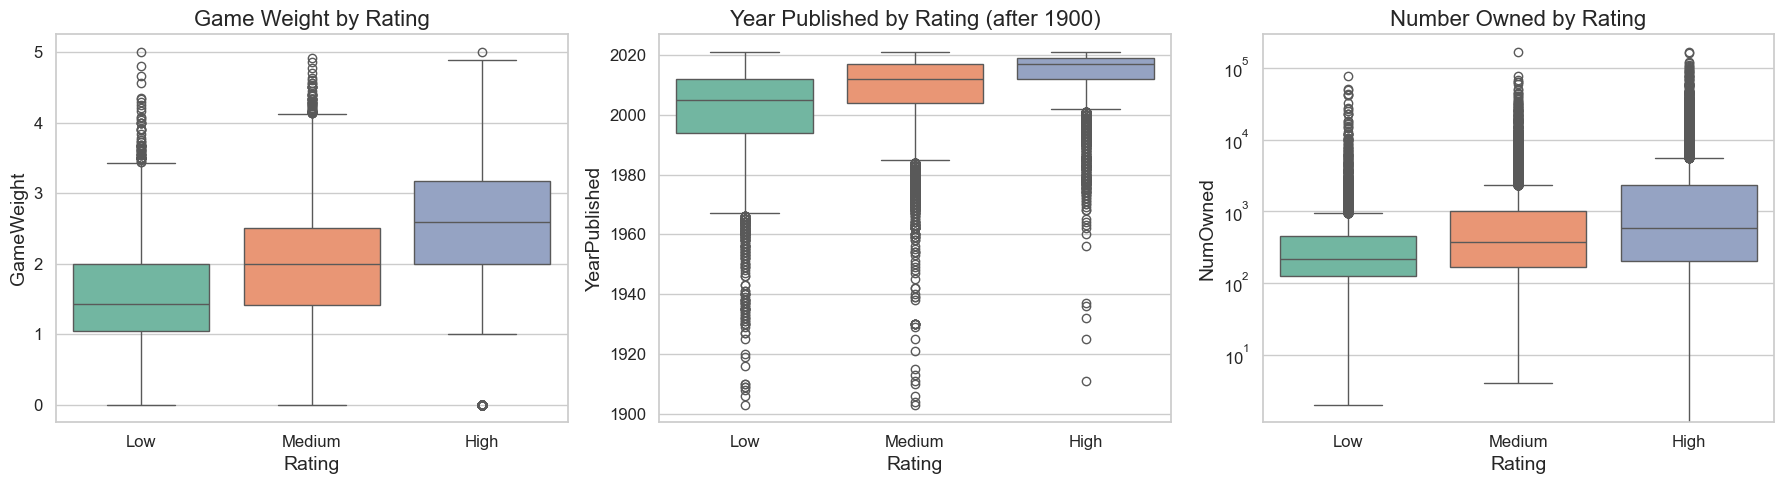

In [9]:
# GameWeight distribution by Rating (grouped boxplot)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(x='Rating', y='GameWeight', data=df, order=order, palette='Set2', ax=axes[0])
axes[0].set_title('Game Weight by Rating')

sns.boxplot(x='Rating', y='YearPublished', data=df[df['YearPublished'] > 1900],
            order=order, palette='Set2', ax=axes[1])
axes[1].set_title('Year Published by Rating (after 1900)')

sns.boxplot(x='Rating', y='NumOwned', data=df, order=order, palette='Set2', ax=axes[2])
axes[2].set_title('Number Owned by Rating')
axes[2].set_yscale('log')

plt.tight_layout()
save_plot(fig, 'task_1/pairwise_boxplots_by_rating.png')
plt.show()


**Discussion:**
- **Game Weight vs Rating**: Higher-rated games tend to have higher complexity. This is a strong signal.
- **Year Published vs Rating**: High-rated games are slightly more recent on average.
- **NumOwned vs Rating**: High-rated games are owned by many more people. The difference is very clear.


Plot saved to: C:\Users\ihsynzd\Documents\Dev\Github\datascience\datamining part 1\src\../report/images\task_1/pairwise_scatterplots.png


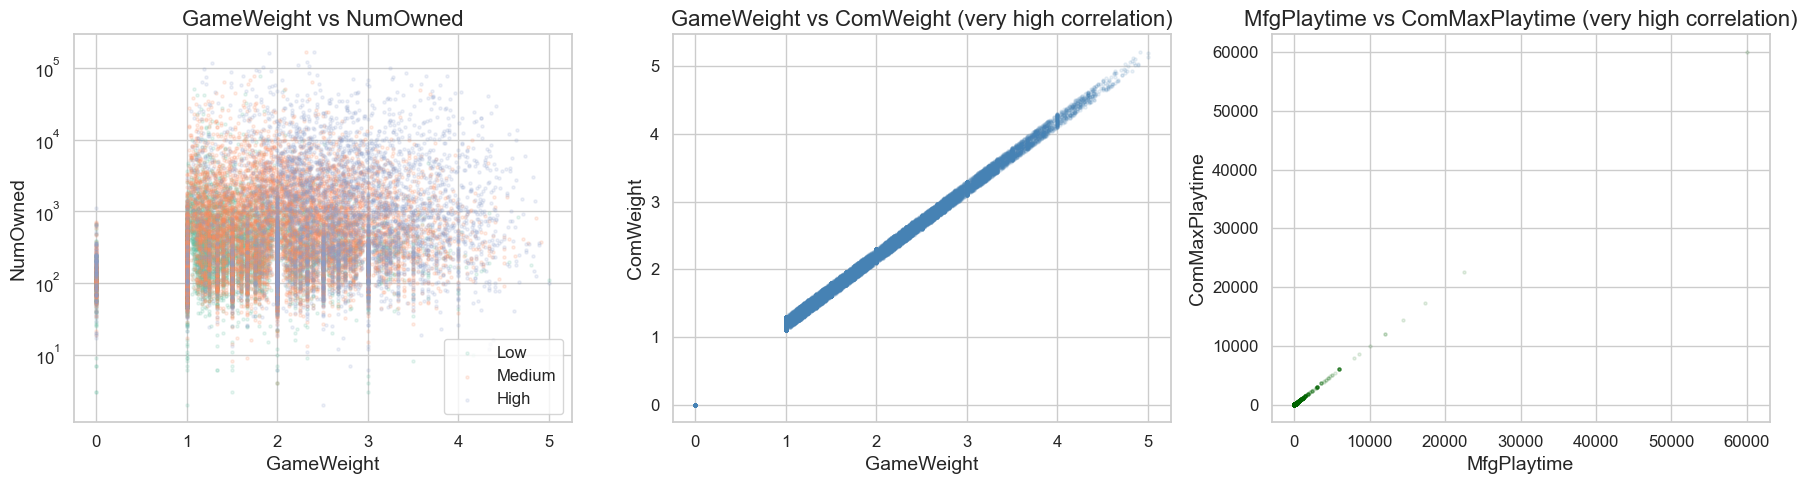

In [10]:
# Scatter plots: pairs of numeric variables
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# GameWeight vs NumOwned (colored by Rating)
for rating, color in zip(order, ['#66c2a5', '#fc8d62', '#8da0cb']):
    subset = df[df['Rating'] == rating]
    axes[0].scatter(subset['GameWeight'], subset['NumOwned'], alpha=0.15, s=5, label=rating, color=color)
axes[0].set_xlabel('GameWeight')
axes[0].set_ylabel('NumOwned')
axes[0].set_yscale('log')
axes[0].set_title('GameWeight vs NumOwned')
axes[0].legend()

# GameWeight vs ComWeight
axes[1].scatter(df['GameWeight'], df['ComWeight'], alpha=0.1, s=5, color='steelblue')
axes[1].set_xlabel('GameWeight')
axes[1].set_ylabel('ComWeight')
axes[1].set_title('GameWeight vs ComWeight (very high correlation)')

# MfgPlaytime vs ComMaxPlaytime
axes[2].scatter(df['MfgPlaytime'], df['ComMaxPlaytime'], alpha=0.1, s=5, color='darkgreen')
axes[2].set_xlabel('MfgPlaytime')
axes[2].set_ylabel('ComMaxPlaytime')
axes[2].set_title('MfgPlaytime vs ComMaxPlaytime (very high correlation)')

plt.tight_layout()
save_plot(fig, 'task_1/pairwise_scatterplots.png')
plt.show()


**Discussion:**
- **GameWeight vs ComWeight**: They are almost the same variable (nearly perfect linear relationship). We can drop one.
- **MfgPlaytime vs ComMaxPlaytime**: Also almost identical. We can keep only one.
- **GameWeight vs NumOwned**: High-rated games (blue) tend to have both higher weight and more owners.


Plot saved to: C:\Users\ihsynzd\Documents\Dev\Github\datascience\datamining part 1\src\../report/images\task_1/category_distribution.png


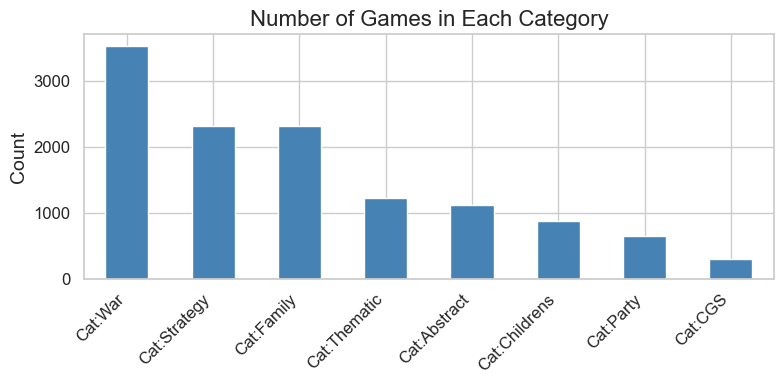

In [11]:
# Binary category columns: how are games distributed across categories?
cat_cols = [c for c in df.columns if c.startswith('Cat:')]
cat_counts = df[cat_cols].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
cat_counts.plot(kind='bar', color='steelblue', ax=ax)
ax.set_title('Number of Games in Each Category')
ax.set_ylabel('Count')
ax.set_xlabel('')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
save_plot(fig, 'task_1/category_distribution.png')
plt.show()


**Discussion:** Cat:War is the largest category, followed by Cat:Strategy and Cat:Family.  
Cat:CGS (card games) is the smallest. Many games belong to no specific category at all.


## 3. Assessing Data Quality and Variable Transformation

The guideline says: *"Are there errors, outliers, missing values, semantic inconsistencies?"*  
And: *"Is it better to use transformed variables (e.g. log-transformed)?"*


### 3.1 Missing values


In [12]:
# Count and show missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'count': missing, 'percent': missing_pct})
missing_df = missing_df[missing_df['count'] > 0].sort_values('percent', ascending=False)
missing_df


,count,percent
Family,15262,69.61
LanguageEase,5891,26.87
ComAgeRec,5530,25.22
ImagePath,17,0.08
Description,1,0.00


**Discussion of missing values:**

| Column | Missing % | Decision | Reason |
|--------|-----------|----------|--------|
| Family | ~69.6% | **Drop column** | Too many missing values to fill. Not useful for models. |
| LanguageEase | ~26.9% | **Fill with median** | The median keeps the center of the distribution. Mean would be affected by outliers. |
| ComAgeRec | ~25.2% | **Fill with median** | Same reason as above. |
| ImagePath | ~0.08% | **Drop column** | This is a URL. Not useful for analysis. |
| Description | ~0.005% | **Drop column** | This is raw text. Not useful for numeric models. |

We also drop **Name** and **GoodPlayers** because:
- Name is a text identifier, not a feature.
- GoodPlayers is stored as a string representation of a list, which is hard to use directly.


### 3.2 Semantic inconsistencies and errors


In [13]:
# 1. YearPublished: check for strange values
print('YearPublished range:', df['YearPublished'].min(), 'to', df['YearPublished'].max())
print(f"Games with YearPublished < 0: {(df['YearPublished'] < 0).sum()}")
print(f"Games with YearPublished < 1800: {(df['YearPublished'] < 1800).sum()}")
print()

# 2. MaxPlayers: check for unrealistic values
print('MaxPlayers range:', df['MaxPlayers'].min(), 'to', df['MaxPlayers'].max())
print(f"Games with MaxPlayers > 100: {(df['MaxPlayers'] > 100).sum()}")
print()

# 3. NumComments: check if it is all zeros
print('NumComments unique values:', df['NumComments'].unique())
print()

# 4. Rank columns: check sentinel value 21926
rank_cols = [c for c in df.columns if c.startswith('Rank:')]
for rc in rank_cols:
    n_sentinel = (df[rc] == 21926).sum()
    print(f'{rc}: {n_sentinel} games have value 21926 (unranked) = {n_sentinel/len(df)*100:.1f}%')


YearPublished range: -3500 to 2021
Games with YearPublished < 0: 11
Games with YearPublished < 1800: 258

MaxPlayers range: 0 to 999
Games with MaxPlayers > 100: 8

NumComments unique values: [0]

Rank:strategygames: 19606 games have value 21926 (unranked) = 89.4%
Rank:abstracts: 20810 games have value 21926 (unranked) = 94.9%
Rank:familygames: 19609 games have value 21926 (unranked) = 89.4%
Rank:thematic: 20701 games have value 21926 (unranked) = 94.4%
Rank:cgs: 21622 games have value 21926 (unranked) = 98.6%
Rank:wargames: 18395 games have value 21926 (unranked) = 83.9%
Rank:partygames: 21285 games have value 21926 (unranked) = 97.1%
Rank:childrensgames: 21044 games have value 21926 (unranked) = 96.0%


**Errors and semantic inconsistencies found:**

1. **YearPublished < 0**: Some games have year -3500. These are ancient games (like Go, Chess). They are not errors in the strict sense, but they are extreme outliers that can hurt distance-based algorithms. We will **clip** YearPublished to a minimum of 1800.

2. **MaxPlayers > 100**: A few games have MaxPlayers = 999 or similar. These are likely placeholder values. We will **cap** MaxPlayers at 100.

3. **NumComments is always 0**: This column gives zero information. We will **drop** it.

4. **Rank columns use 21926 as sentinel for 'unranked'**: The value 21926 is not a real rank -- it means the game is not ranked in that category. Most games are unranked in most categories (>80%). This inflates the statistics. We leave these as-is for now, since they will be useful in later tasks as a numeric proxy.


### 3.3 Outlier detection using IQR method


In [14]:
def detect_outliers_iqr(series):
    """Find outliers using the IQR (Inter Quartile Range) rule."""
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = series[(series < lower) | (series > upper)]
    return len(outliers), lower, upper

# Run IQR outlier check on key numeric columns
outlier_cols = ['YearPublished', 'GameWeight', 'MinPlayers', 'MaxPlayers',
                'NumOwned', 'MfgPlaytime', 'NumUserRatings', 'LanguageEase',
                'NumWant', 'NumWish', 'NumExpansions', 'NumAlternates']

outlier_results = []
for col in outlier_cols:
    count, lower, upper = detect_outliers_iqr(df[col].dropna())
    outlier_results.append({'Column': col, 'Outlier Count': count,
                            'Lower Bound': round(lower, 2), 'Upper Bound': round(upper, 2)})

outlier_df = pd.DataFrame(outlier_results)
outlier_df


,Column,Outlier Count,Lower Bound,Upper Bound
0,YearPublished,1143,1977.00,2041.00
1,GameWeight,134,-0.45,4.31
2,MinPlayers,6886,2.00,2.00
3,MaxPlayers,1340,1.00,9.00
4,NumOwned,2845,-973.50,2022.50
5,MfgPlaytime,1463,-72.50,187.50
6,NumUserRatings,3110,-452.50,903.50
7,LanguageEase,257,-466.43,841.46
8,NumWant,2910,-34.50,65.50
9,NumWish,3030,-155.50,296.50


**Discussion:**  
Many columns have a large number of IQR-outliers. This is because the data is naturally very skewed (many games are unknown, a few are very popular).  
We will **not** remove all outliers blindly. Instead, we will:
- Fix clear errors (YearPublished < 1800, MaxPlayers > 100).
- For heavily skewed columns, we will test **log transformations** to reduce the effect of outliers.


### 3.4 Variable transformation: log-transform for skewed variables
The guideline asks: *"Is it better to use transformed variables (e.g. log-transformed)?"*  
Let us compare the original vs log-transformed distributions for the most skewed variables.


Plot saved to: C:\Users\ihsynzd\Documents\Dev\Github\datascience\datamining part 1\src\../report/images\task_1/log_transformation_comparison.png


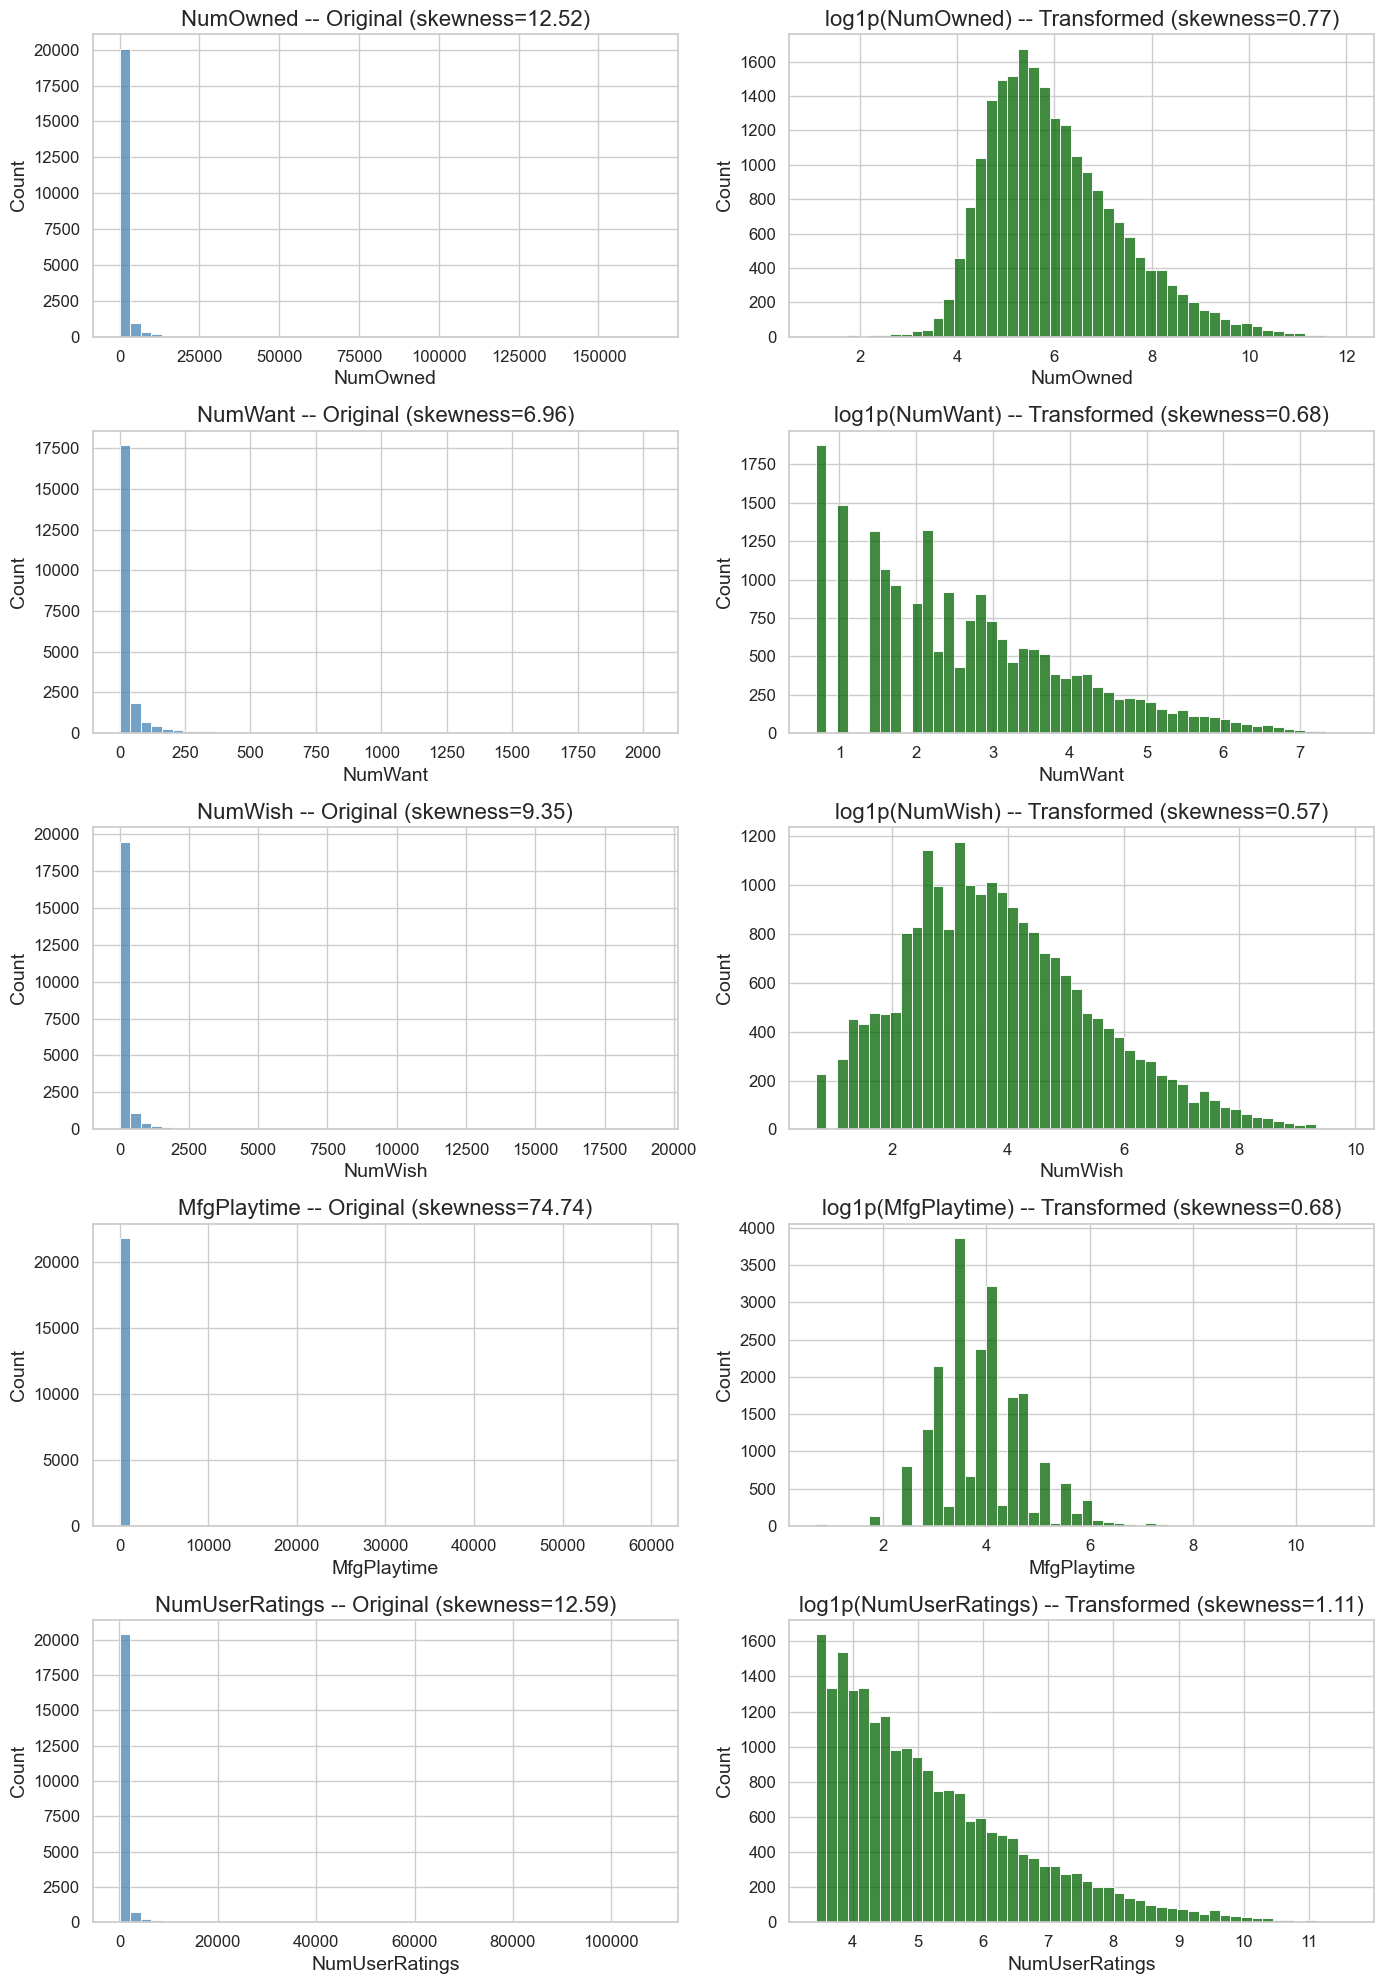

In [15]:
skewed_cols = ['NumOwned', 'NumWant', 'NumWish', 'MfgPlaytime', 'NumUserRatings']

fig, axes = plt.subplots(len(skewed_cols), 2, figsize=(14, 4 * len(skewed_cols)))

for i, col in enumerate(skewed_cols):
    data = df[col].dropna()
    # Remove zeros for log (log(0) is undefined)
    data_pos = data[data > 0]

    # Original
    skew_orig = data.skew()
    sns.histplot(data, bins=50, ax=axes[i, 0], color='steelblue')
    axes[i, 0].set_title(f'{col} -- Original (skewness={skew_orig:.2f})')

    # Log-transformed
    log_data = np.log1p(data_pos)  # log(1 + x) to handle small values safely
    skew_log = log_data.skew()
    sns.histplot(log_data, bins=50, ax=axes[i, 1], color='darkgreen')
    axes[i, 1].set_title(f'log1p({col}) -- Transformed (skewness={skew_log:.2f})')

plt.tight_layout()
save_plot(fig, 'task_1/log_transformation_comparison.png')
plt.show()


**Discussion:**  
The log transformation clearly reduces skewness for all these variables.  
For example:
- **NumOwned** goes from very high skewness to near-normal shape.
- **MfgPlaytime** also becomes much more symmetric.

**Decision:** We will store the log-transformed versions of these 5 columns in the cleaned dataset as extra features, so they can be used in clustering and regression where normality helps.


### 3.5 Apply all cleaning steps
Now we apply every fix we discussed above in one place.


In [16]:
clean_df = df.copy()

# --- 1. Drop columns that are not useful ---
cols_to_drop = ['Family', 'ImagePath', 'Description', 'Name', 'GoodPlayers', 'NumComments']
clean_df = clean_df.drop(columns=cols_to_drop)
print(f'Dropped {len(cols_to_drop)} columns: {cols_to_drop}')

# --- 2. Fill missing values ---
clean_df['ComAgeRec'] = clean_df['ComAgeRec'].fillna(clean_df['ComAgeRec'].median())
clean_df['LanguageEase'] = clean_df['LanguageEase'].fillna(clean_df['LanguageEase'].median())
print(f'Filled ComAgeRec and LanguageEase missing values with median.')

# --- 3. Fix errors ---
# Clip YearPublished to minimum 1800
n_clipped_year = (clean_df['YearPublished'] < 1800).sum()
clean_df['YearPublished'] = clean_df['YearPublished'].clip(lower=1800)
print(f'Clipped {n_clipped_year} games with YearPublished < 1800.')

# Cap MaxPlayers at 100
n_capped_players = (clean_df['MaxPlayers'] > 100).sum()
clean_df['MaxPlayers'] = clean_df['MaxPlayers'].clip(upper=100)
print(f'Capped {n_capped_players} games with MaxPlayers > 100.')

# --- 4. Add log-transformed columns for skewed variables ---
for col in ['NumOwned', 'NumWant', 'NumWish', 'MfgPlaytime', 'NumUserRatings']:
    clean_df[f'log_{col}'] = np.log1p(clean_df[col])
print('Added log-transformed columns for 5 skewed variables.')

print(f'\nMissing values remaining: {clean_df.isnull().sum().sum()}')
print(f'Shape after cleaning: {clean_df.shape}')


Dropped 6 columns: ['Family', 'ImagePath', 'Description', 'Name', 'GoodPlayers', 'NumComments']
Filled ComAgeRec and LanguageEase missing values with median.
Clipped 258 games with YearPublished < 1800.
Capped 8 games with MaxPlayers > 100.
Added log-transformed columns for 5 skewed variables.

Missing values remaining: 0
Shape after cleaning: (21925, 45)


## 4. Pairwise Correlations and Elimination of Variables

The guideline says: *"Matrix correlation (analyse high correlated variables)."*  
We compute the full correlation matrix, visualize it, and then list all pairs with |r| > 0.85.


Plot saved to: C:\Users\ihsynzd\Documents\Dev\Github\datascience\datamining part 1\src\../report/images\task_1/correlation_matrix_full.png


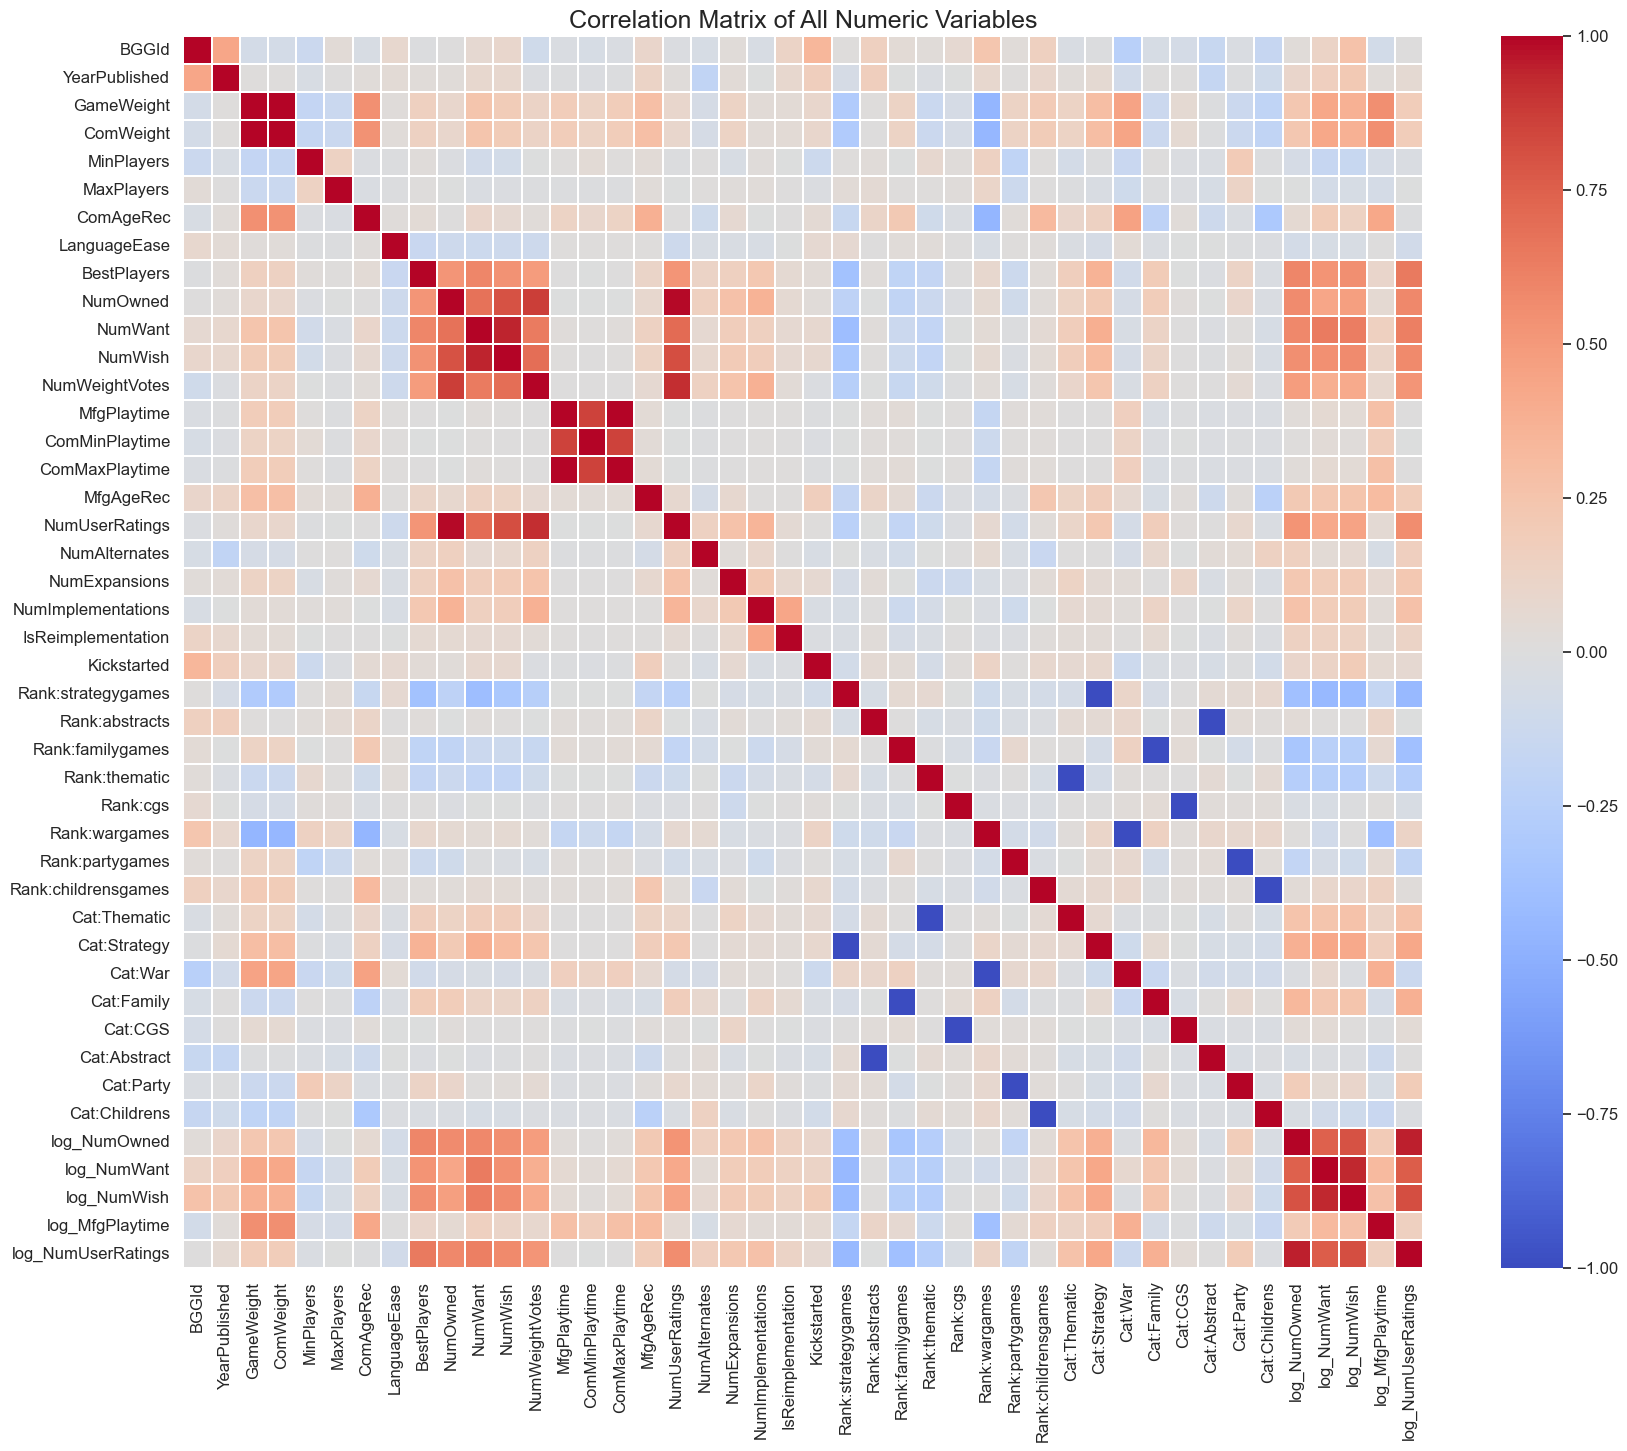

In [17]:
# Compute correlation matrix for numeric columns
numeric_df = clean_df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

# Draw the full heatmap
fig, ax = plt.subplots(figsize=(20, 16))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, vmin=-1, vmax=1,
            linewidths=0.3, ax=ax)
ax.set_title('Correlation Matrix of All Numeric Variables', fontsize=18)
save_plot(fig, 'task_1/correlation_matrix_full.png')
plt.show()


### 4.1 Highly correlated pairs (|r| > 0.85)


In [18]:
# Find all pairs with absolute correlation > 0.85
threshold = 0.85

# Get the upper triangle of the correlation matrix (no duplicates)
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Collect pairs above threshold
high_corr_pairs = []
for col in upper_tri.columns:
    for idx in upper_tri.index:
        val = upper_tri.loc[idx, col]
        if pd.notna(val) and abs(val) > threshold:
            high_corr_pairs.append({'Variable 1': idx, 'Variable 2': col, 'Correlation': round(val, 4)})

high_corr_df = pd.DataFrame(high_corr_pairs).sort_values('Correlation', ascending=False, key=abs)
high_corr_df


,Variable 1,Variable 2,Correlation
14,Rank:partygames,Cat:Party,-1.0000
4,MfgPlaytime,ComMaxPlaytime,1.0000
12,Rank:cgs,Cat:CGS,-1.0000
15,Rank:childrensgames,Cat:Childrens,-0.9999
13,Rank:abstracts,Cat:Abstract,-0.9999
8,Rank:thematic,Cat:Thematic,-0.9999
9,Rank:strategygames,Cat:Strategy,-0.9994
11,Rank:familygames,Cat:Family,-0.9994
10,Rank:wargames,Cat:War,-0.9985
0,GameWeight,ComWeight,0.9973


### 4.2 Decision: which correlated columns to drop

Based on the table above, here is our decision for each highly correlated pair:

| Pair | Correlation | Drop | Reason |
|------|------------|------|--------|
| MfgPlaytime & ComMaxPlaytime | ~1.00 | ComMaxPlaytime | They are almost the same. Keep manufacturer version. |
| ComMinPlaytime & ComMaxPlaytime | ~0.99 | ComMinPlaytime | Already dropping ComMaxPlaytime; drop ComMinPlaytime too. |
| GameWeight & ComWeight | ~0.97 | ComWeight | Very similar complexity scores. Keep the original GameWeight. |
| NumOwned & NumUserRatings | ~0.95 | NumUserRatings | Both measure popularity. Keep NumOwned as the main one. |
| NumWant & NumWish | ~0.90 | NumWant | Both measure user interest. Keep NumWish as it has more variation. |
| log versions of above | ~same | same logic | Log versions follow the same pattern. |

We also drop **BGGId** because it is just an identifier, not a feature.


In [19]:
# Drop the columns we decided to remove
cols_to_remove = ['ComMaxPlaytime', 'ComMinPlaytime', 'ComWeight',
                  'NumUserRatings', 'NumWant', 'BGGId',
                  'log_NumUserRatings', 'log_NumWant']

# Only drop columns that actually exist in the dataframe
cols_to_remove = [c for c in cols_to_remove if c in clean_df.columns]
clean_df = clean_df.drop(columns=cols_to_remove)

print(f'Dropped {len(cols_to_remove)} highly correlated / identifier columns:')
for c in cols_to_remove:
    print(f'  - {c}')
print(f'\nFinal shape: {clean_df.shape}')


Dropped 8 highly correlated / identifier columns:
  - ComMaxPlaytime
  - ComMinPlaytime
  - ComWeight
  - NumUserRatings
  - NumWant
  - BGGId
  - log_NumUserRatings
  - log_NumWant

Final shape: (21925, 37)


### 4.3 Final correlation matrix after removal
Let us check the heatmap again to make sure no extreme correlations remain.


Plot saved to: C:\Users\ihsynzd\Documents\Dev\Github\datascience\datamining part 1\src\../report/images\task_1/correlation_matrix_final.png


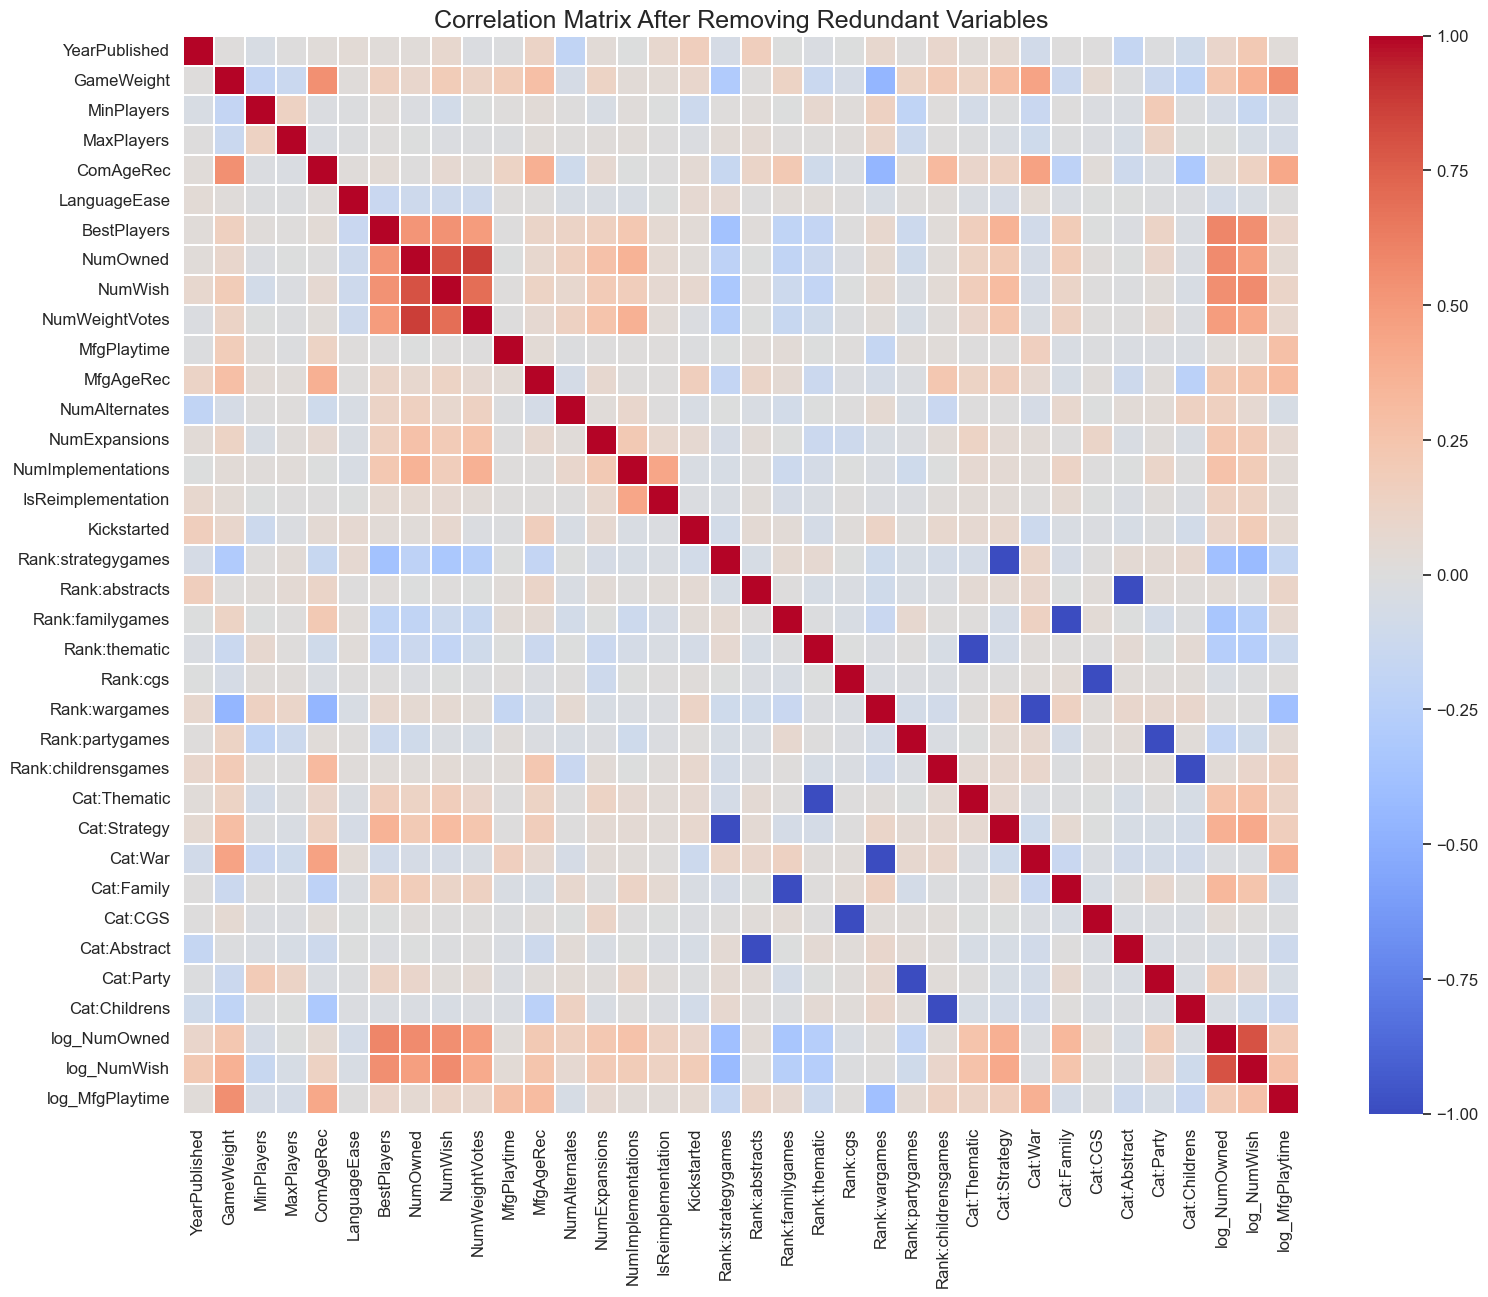

In [20]:
numeric_final = clean_df.select_dtypes(include=[np.number])
corr_final = numeric_final.corr()

fig, ax = plt.subplots(figsize=(18, 14))
sns.heatmap(corr_final, cmap='coolwarm', center=0, vmin=-1, vmax=1,
            linewidths=0.3, annot=False, ax=ax)
ax.set_title('Correlation Matrix After Removing Redundant Variables', fontsize=18)
save_plot(fig, 'task_1/correlation_matrix_final.png')
plt.show()


## 5. Save the Cleaned Dataset
We save the cleaned data so we can use it directly in Task 2 (Clustering) and Task 3 (Classification & Regression).


In [21]:
os.makedirs('../dataset/processed', exist_ok=True)

clean_path = '../dataset/processed/DM1_game_dataset_clean.csv'
clean_df.to_csv(clean_path, index=False)
print(f'Cleaned data saved to: {clean_path}')
print(f'Final shape: {clean_df.shape}')
print(f'Columns: {list(clean_df.columns)}')


Cleaned data saved to: ../dataset/processed/DM1_game_dataset_clean.csv
Final shape: (21925, 37)
Columns: ['YearPublished', 'GameWeight', 'MinPlayers', 'MaxPlayers', 'ComAgeRec', 'LanguageEase', 'BestPlayers', 'NumOwned', 'NumWish', 'NumWeightVotes', 'MfgPlaytime', 'MfgAgeRec', 'NumAlternates', 'NumExpansions', 'NumImplementations', 'IsReimplementation', 'Kickstarted', 'Rank:strategygames', 'Rank:abstracts', 'Rank:familygames', 'Rank:thematic', 'Rank:cgs', 'Rank:wargames', 'Rank:partygames', 'Rank:childrensgames', 'Cat:Thematic', 'Cat:Strategy', 'Cat:War', 'Cat:Family', 'Cat:CGS', 'Cat:Abstract', 'Cat:Party', 'Cat:Childrens', 'Rating', 'log_NumOwned', 'log_NumWish', 'log_MfgPlaytime']


## Summary of Data Understanding & Preparation

| Step | What we did | Key findings |
|------|------------|-------------|
| Data Semantics | Described all 46 variables with type and meaning | 6 text/id columns, 8 binary, 1 ordinal target, rest numeric |
| Distributions | Plotted histograms, boxplots, and pairwise charts | Many right-skewed variables; Rating is somewhat imbalanced |
| Data Quality | Found errors, outliers, and semantic problems | YearPublished errors, MaxPlayers errors, NumComments all zeros, Rank sentinel values |
| Transformations | Tested log1p on 5 skewed variables | Log reduces skewness significantly; added as extra columns |
| Missing Values | Filled ComAgeRec & LanguageEase with median; dropped Family | Justified each choice based on missing % and usefulness |
| Correlations | Found 5+ pairs with |r| > 0.85, removed redundant ones | Dropped ComWeight, ComMinPlaytime, ComMaxPlaytime, NumUserRatings, NumWant |

The cleaned dataset is now ready for the next tasks.
